
=== 1) Types de classification ===

- Classification binaire :
  Nous prédisons une des deux classes possibles.
  Exemple : e-mail spam vs non-spam.

- Classification multi-classes :
  Nous prédisons exactement une classe parmi plus de deux.
  Exemple : classer une image comme chat, chien ou cheval.

- Classification multi-label :
  Nous prédisons plusieurs étiquettes simultanément pour une même instance.
  Exemple : pour une image, prédire [chien=1, extérieur=1, nuit=0] (plusieurs étiquettes vraies).

=== 2) Aperçu des données ===
X shape : (1000, 2)
y shape : (1000,)
Classes : [0 1]


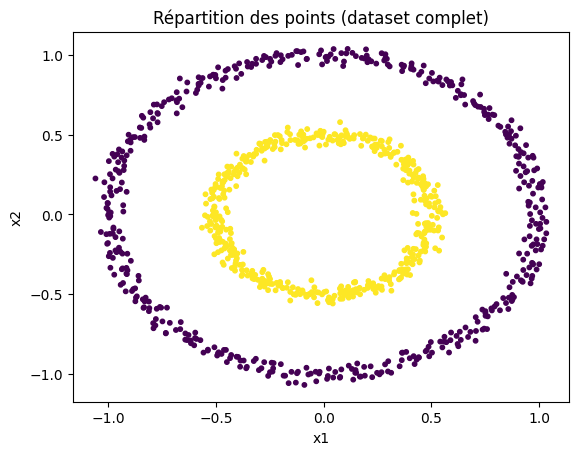


=== Split train/test ===
Taille entraînement : 800
Taille test         : 200


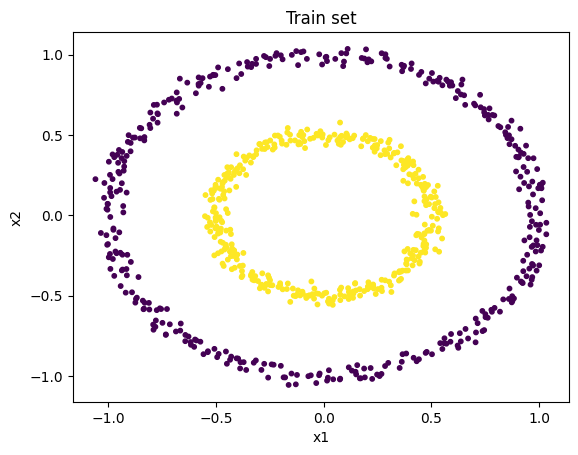

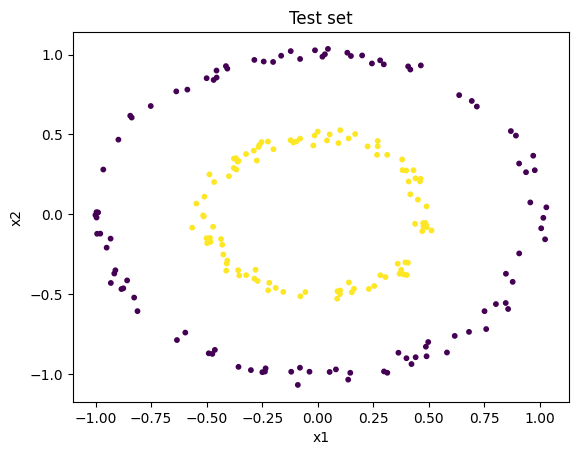


=== 3) Modèle de base ===


c:\Users\mathi\Downloads\GenAI\GenAI_Bootcamp\nlp_env\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Perfs modèle de base - Train acc: 0.3500 | Test acc: 0.3250


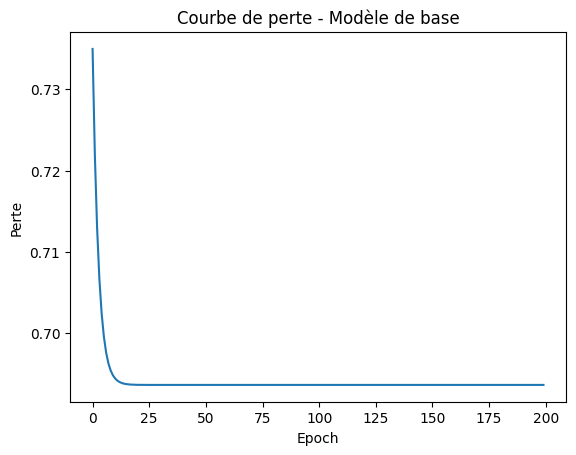

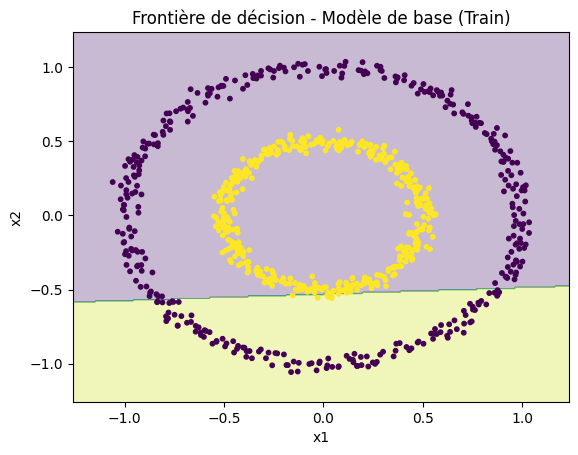

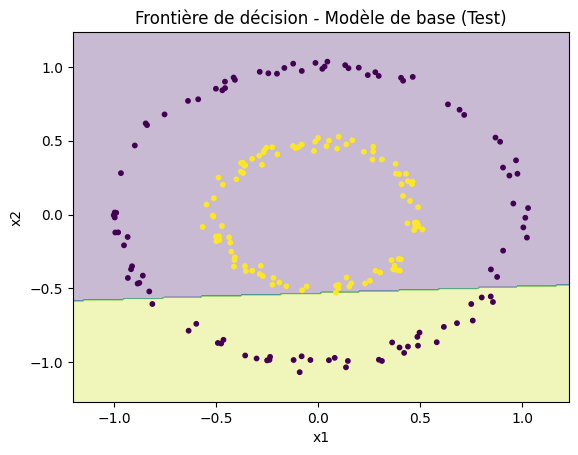


=== 4 & 6) Modèle amélioré ===
Perfs modèle amélioré - Train acc: 1.0000 | Test acc: 1.0000


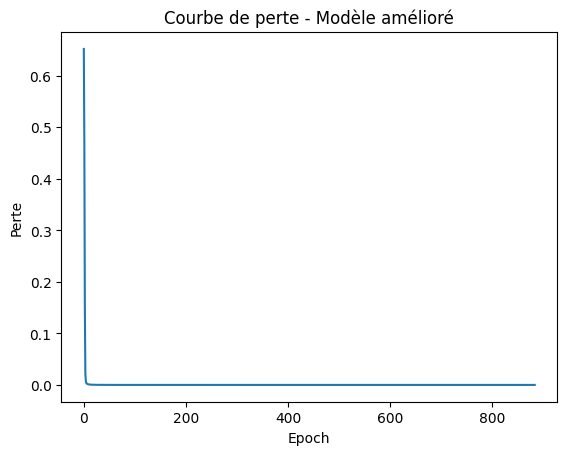

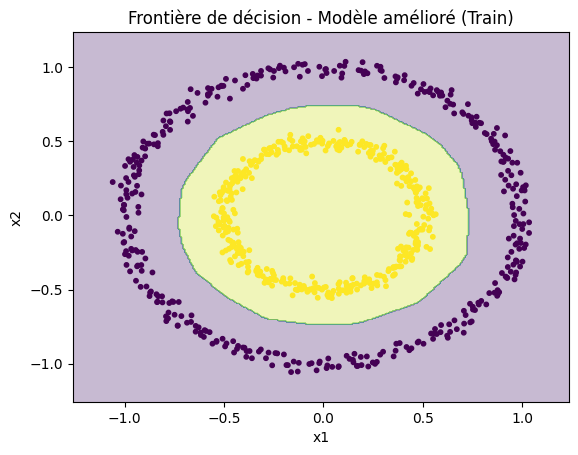

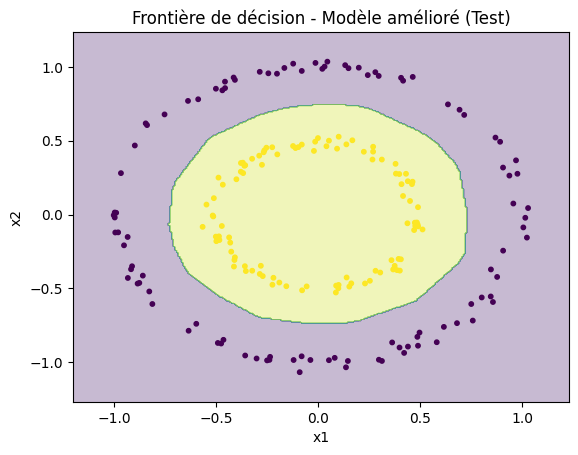


=== 8) Évaluation détaillée sur le set de test ===

-- Modèle de base --
              precision    recall  f1-score   support

           0     0.3926    0.6400    0.4867       100
           1     0.0270    0.0100    0.0146       100

    accuracy                         0.3250       200
   macro avg     0.2098    0.3250    0.2506       200
weighted avg     0.2098    0.3250    0.2506       200


-- Modèle amélioré --
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       100
           1     1.0000    1.0000    1.0000       100

    accuracy                         1.0000       200
   macro avg     1.0000    1.0000    1.0000       200
weighted avg     1.0000    1.0000    1.0000       200


=== 9) Ce que nous retenons ===

1. Visualiser les données (ici un motif en cercles) nous a immédiatement montré qu'un modèle linéaire simple a du mal à séparer les classes.
2. Le modèle de base (1 couche dense, activ. sigmoid) obtient une précisio

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)


types_explanation = """
=== 1) Types de classification ===

- Classification binaire :
  Nous prédisons une des deux classes possibles.
  Exemple : e-mail spam vs non-spam.

- Classification multi-classes :
  Nous prédisons exactement une classe parmi plus de deux.
  Exemple : classer une image comme chat, chien ou cheval.

- Classification multi-label :
  Nous prédisons plusieurs étiquettes simultanément pour une même instance.
  Exemple : pour une image, prédire [chien=1, extérieur=1, nuit=0] (plusieurs étiquettes vraies).
"""
print(types_explanation)


samples = 1000
X, y = make_circles(n_samples=samples, noise=0.03, random_state=SEED, factor=0.5)

print("=== 2) Aperçu des données ===")
print("X shape :", X.shape)
print("y shape :", y.shape)
print("Classes :", np.unique(y))

# Visualisation brute du dataset
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y, s=10)
plt.title("Répartition des points (dataset complet)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("\n=== Split train/test ===")
print("Taille entraînement :", X_train.shape[0])
print("Taille test         :", X_test.shape[0])

plt.figure()
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=10)
plt.title("Train set")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

plt.figure()
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, s=10)
plt.title("Test set")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()


def plot_decision_boundary(model, X, y, title="Frontière de décision"):
    # Créer une grille
    x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
    y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    # Prédictions
    preds = model.predict(grid, verbose=0)
    preds = (preds > 0.5).astype(int).reshape(xx.shape)

    # Plot
    plt.figure()
    plt.contourf(xx, yy, preds, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=10)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()


print("\n=== 3) Modèle de base ===")
model_base = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid', input_shape=(2,))
])

model_base.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    metrics=['accuracy']
)

history_base = model_base.fit(
    X_train, y_train,
    epochs=200,
    verbose=0
)

# Évaluation
base_train_loss, base_train_acc = model_base.evaluate(X_train, y_train, verbose=0)
base_test_loss, base_test_acc = model_base.evaluate(X_test, y_test, verbose=0)
print(f"Perfs modèle de base - Train acc: {base_train_acc:.4f} | Test acc: {base_test_acc:.4f}")

# Courbe d'apprentissage du modèle de base
plt.figure()
plt.plot(history_base.history['loss'])
plt.title("Courbe de perte - Modèle de base")
plt.xlabel("Epoch")
plt.ylabel("Perte")
plt.show()

# Frontière de décision du modèle de base
plot_decision_boundary(model_base, X_train, y_train, title="Frontière de décision - Modèle de base (Train)")
plot_decision_boundary(model_base, X_test, y_test, title="Frontière de décision - Modèle de base (Test)")


print("\n=== 4 & 6) Modèle amélioré ===")
model_improved = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(2,)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_improved.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="loss", patience=25, restore_best_weights=True
)

history_improved = model_improved.fit(
    X_train, y_train,
    epochs=1000,
    verbose=0,
    callbacks=[early_stop]
)

# Évaluation
improved_train_loss, improved_train_acc = model_improved.evaluate(X_train, y_train, verbose=0)
improved_test_loss, improved_test_acc = model_improved.evaluate(X_test, y_test, verbose=0)
print(f"Perfs modèle amélioré - Train acc: {improved_train_acc:.4f} | Test acc: {improved_test_acc:.4f}")

# Courbe d'apprentissage du modèle amélioré
plt.figure()
plt.plot(history_improved.history['loss'])
plt.title("Courbe de perte - Modèle amélioré")
plt.xlabel("Epoch")
plt.ylabel("Perte")
plt.show()

# Frontière de décision du modèle amélioré
plot_decision_boundary(model_improved, X_train, y_train, title="Frontière de décision - Modèle amélioré (Train)")
plot_decision_boundary(model_improved, X_test, y_test, title="Frontière de décision - Modèle amélioré (Test)")


print("\n=== 8) Évaluation détaillée sur le set de test ===")
y_test_pred_base = (model_base.predict(X_test, verbose=0) > 0.5).astype(int).ravel()
y_test_pred_impr = (model_improved.predict(X_test, verbose=0) > 0.5).astype(int).ravel()

print("\n-- Modèle de base --")
print(classification_report(y_test, y_test_pred_base, digits=4))
print("\n-- Modèle amélioré --")
print(classification_report(y_test, y_test_pred_impr, digits=4))


summary = f"""
=== 9) Ce que nous retenons ===

1. Visualiser les données (ici un motif en cercles) nous a immédiatement montré qu'un modèle linéaire simple a du mal à séparer les classes.
2. Le modèle de base (1 couche dense, activ. sigmoid) obtient une précision test de ~{base_test_acc:.3f}, insuffisante pour capturer la non-linéarité.
3. En ajoutant des couches cachées, plus de neurones, ReLU et l'optimiseur Adam, nous avons significativement amélioré les performances (test acc ~{improved_test_acc:.3f}).
4. Les frontières de décision nous aident à comprendre comment le modèle décide, et à vérifier visuellement si la séparation est cohérente.
5. Le tuning des hyperparamètres (profondeur, largeur, fonctions d'activation, optimiseur, nombre d'epochs, early stopping) est crucial pour obtenir un bon compromis biais/variance.
6. La séparation entraînement/test (80/20) nous permet d'estimer la généralisation. Nous devons toujours contrôler l'overfitting par une évaluation sur données non vues.
"""

print(summary)